/tmp/ipykernel_1821/1493587354.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Dataset Downloaded Successfully!
Price            Close        High         Low        Open    Volume
Date                                                                
2021-01-01  897.047119  901.334860  894.564705  897.272755  10015175
2021-01-04  898.559082  902.192359  888.245845  900.477287  24513534
2021-01-05  887.388245  895.286758  882.829622  888.697112  24123091
2021-01-06  863.986145  887.343173  859.878913  887.298046  46401468
2021-01-07  862.586975  877.864981  859.878925  866.807025  32325918

Dataset Information
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1236 entries, 2021-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1236 non-null   float64
 1   High    1236 non-null   float64
 2   Low     1236 non-null   float64
 3   Open    1236 non-null   float64
 4   Volume  1236 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 57.9 KB
None

Missing Values
Price
C

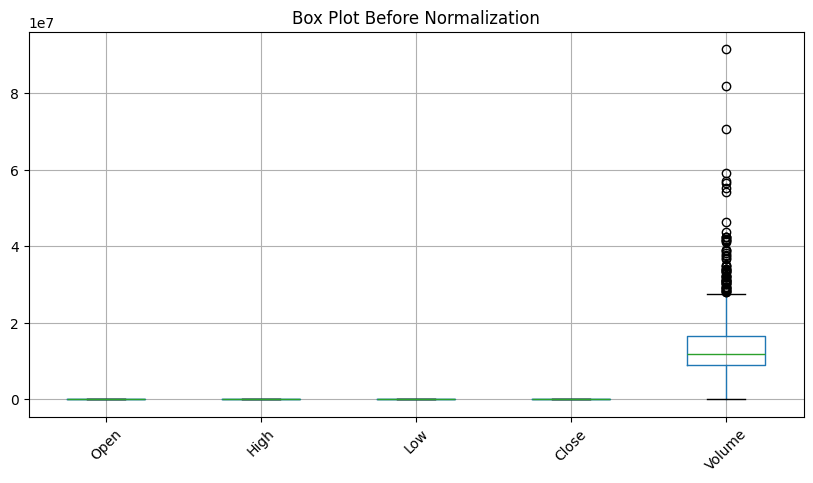

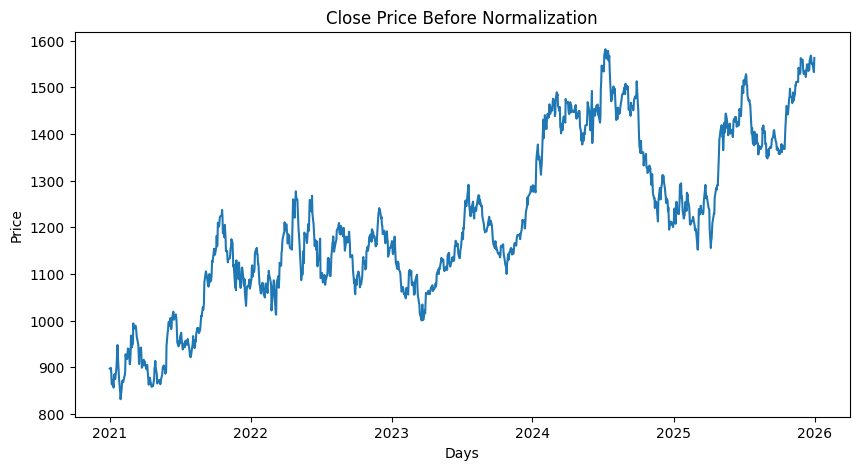


Min-Max Normalized Data
Price           Open      High       Low     Close    Volume
Date                                                        
2021-01-01  0.077795  0.056896  0.092628  0.087536  0.109501
2021-01-04  0.082090  0.058071  0.084096  0.089551  0.268019
2021-01-05  0.066301  0.048609  0.076783  0.074666  0.263750
2021-01-06  0.064426  0.037725  0.045796  0.043482  0.507331
2021-01-07  0.036962  0.024737  0.045796  0.041618  0.353436

Z-Score Normalized Data
Price           Open      High       Low     Close    Volume
Date                                                        
2021-01-01 -1.783870 -1.815674 -1.739450 -1.780286 -0.495347
2021-01-04 -1.765896 -1.810884 -1.774965 -1.771817  1.330257
2021-01-05 -1.831970 -1.849461 -1.805407 -1.834389  1.281093
2021-01-06 -1.839817 -1.893837 -1.934402 -1.965472  4.086341
2021-01-07 -1.954749 -1.946785 -1.934402 -1.973309  2.313977

Comparison of Original vs Normalized Values
            Original_Close  MinMax_Close  ZScore_Cl

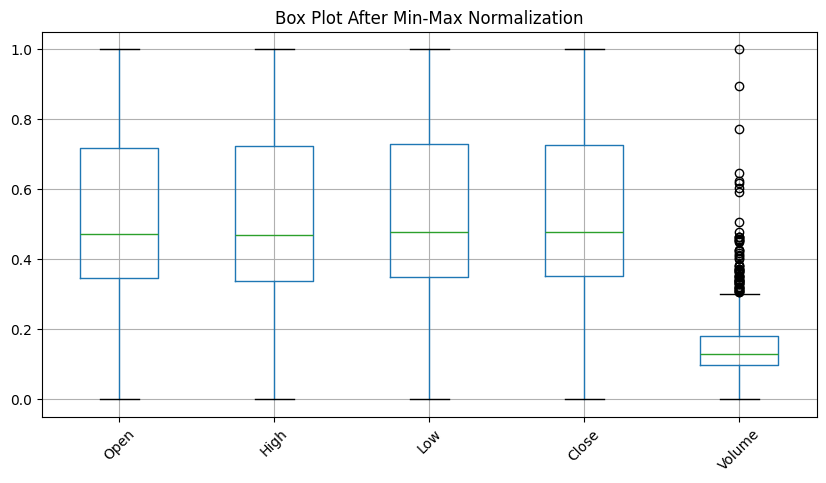

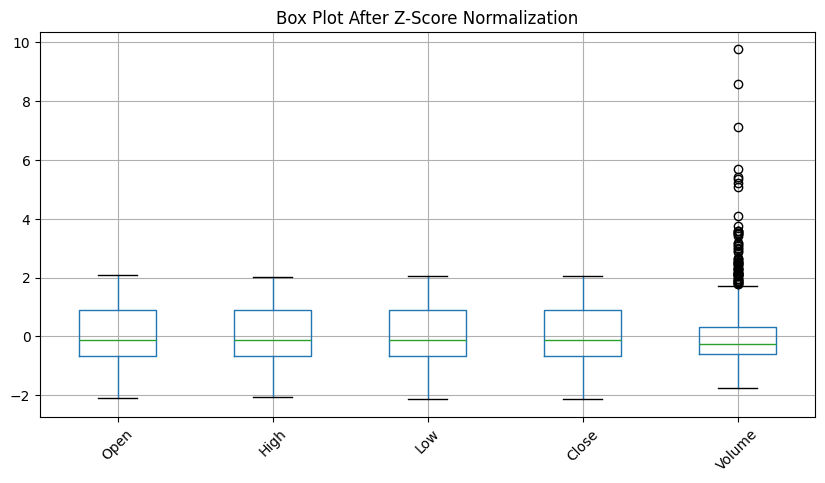

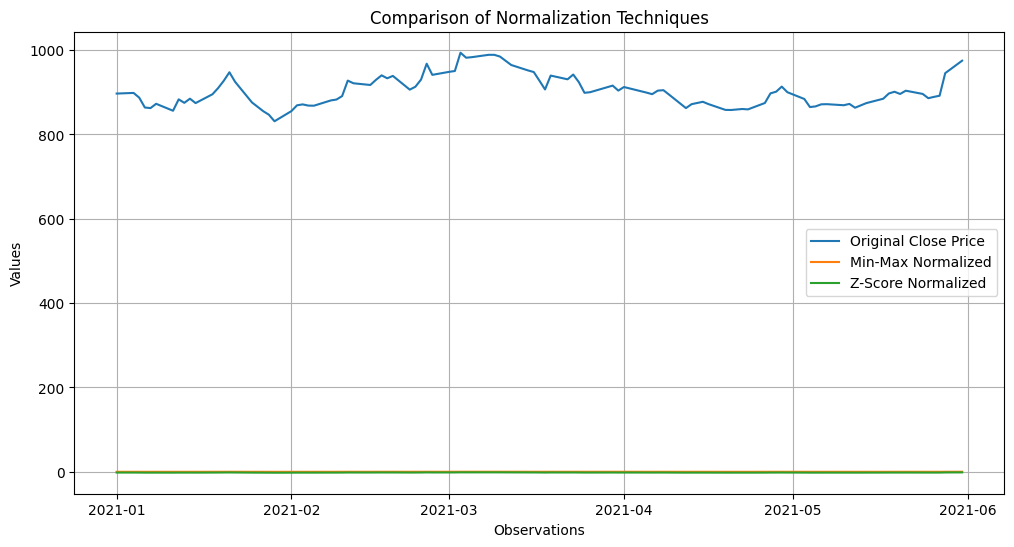


Original Data Statistics
Price         Open         High          Low        Close        Volume
count  1236.000000  1236.000000  1236.000000  1236.000000  1.236000e+03
mean   1215.314582  1226.353205  1204.046845  1214.878504  1.394906e+07
std     178.359748   179.079456   177.991596   178.600535  7.944892e+06
min     839.229814   859.811100   825.960225   831.353821  0.000000e+00
25%    1097.893671  1106.025452  1085.023047  1095.659424  9.046766e+06
50%    1191.266409  1202.927423  1179.453744  1189.996460  1.199445e+07
75%    1375.892760  1388.679838  1365.800297  1376.709686  1.650136e+07
max    1585.332124  1589.630354  1566.607971  1581.824463  9.146198e+07

Min-Max Statistics
Price         Open         High          Low        Close       Volume
count  1236.000000  1236.000000  1236.000000  1236.000000  1236.000000
mean      0.504066     0.502237     0.510481     0.511046     0.152512
std       0.239055     0.245375     0.240319     0.237985     0.086866
min       0.000000    

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("Downloading Stock Dataset...")

df = yf.download(
    "RELIANCE.NS",
    start="2021-01-01",
    end="2026-01-01"
)

# Flatten the MultiIndex columns to single-level column names
df.columns = df.columns.droplevel(1)

df.to_csv("reliance_stock.csv")

print("\nDataset Downloaded Successfully!")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nNumber of Duplicate Records:",
      df.duplicated().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning:", df.shape)

num_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(10,5))
df[num_cols].boxplot()
plt.title("Box Plot Before Normalization")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Close Price Before Normalization")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()

df_minmax[num_cols] = minmax_scaler.fit_transform(
    df[num_cols]
)

print("\nMin-Max Normalized Data")
print(df_minmax[num_cols].head())

zscore_scaler = StandardScaler()

df_zscore = df.copy()

df_zscore[num_cols] = zscore_scaler.fit_transform(
    df[num_cols]
)

print("\nZ-Score Normalized Data")
print(df_zscore[num_cols].head())

comparison = pd.DataFrame({
    "Original_Close": df['Close'].head(10),
    "MinMax_Close": df_minmax['Close'].head(10),
    "ZScore_Close": df_zscore['Close'].head(10)
})

print("\nComparison of Original vs Normalized Values")
print(comparison)

plt.figure(figsize=(10,5))
df_minmax[num_cols].boxplot()
plt.title("Box Plot After Min-Max Normalization")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
df_zscore[num_cols].boxplot()
plt.title("Box Plot After Z-Score Normalization")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))

plt.plot(
    df['Close'].head(100),
    label='Original Close Price'
)

plt.plot(
    df_minmax['Close'].head(100),
    label='Min-Max Normalized'
)

plt.plot(
    df_zscore['Close'].head(100),
    label='Z-Score Normalized'
)

plt.title("Comparison of Normalization Techniques")
plt.xlabel("Observations")
plt.ylabel("Values")
plt.legend()
plt.grid(True)

plt.show()

print("\nOriginal Data Statistics")
print(df[num_cols].describe())

print("\nMin-Max Statistics")
print(df_minmax[num_cols].describe())

print("\nZ-Score Statistics")
print(df_zscore[num_cols].describe())

print("\nProgram Executed Successfully!")